In [ ]:
# Required directories
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [ ]:
# importing the dataset
data = '/content/Final.csv'
dfh = pd.read_csv(data)
dfh

,Countries and areas,Region,Income Group,Life Expectancy,Healthy Life Expectancy,Cancer,Suicide,Alcohol Consumption,Road Accidents,Obesity,Malaria,Hypertension,Tuberculosis,Sanitation
0,Afghanistan,South Asia,Low income,63.2,53.9,35.3,4.1,0.1,15.9,5.5,6.3,40.2,189.0,16.6
1,Albania,Europe & Central Asia,Upper middle income,78,69.1,11.4,4.3,5.1,11.7,21.7,-,41.8,17.0,3.2
2,Algeria,Middle East & North Africa,Lower middle income,77.1,66.4,13.9,2.5,0.6,20.9,27.4,0,36.2,54.0,4.1
3,Andorra,Europe & Central Asia,High income,-,-,-,-,11.1,-,25.6,-,31,2.9,-
4,Angola,Sub-Saharan Africa,Lower middle income,63.1,54.8,22.2,6.1,6.2,26.1,8.2,254.9,38.7,325.0,48.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Venezuela (Bolivarian Republic of),Latin America & Caribbean,Upper middle income,73.9,64.4,14.8,2,3,39,25.6,14.5,39.4,47.0,5.2
194,Viet Nam,East Asia & Pacific,Lower middle income,73.7,65.3,21.2,7.5,9.3,30.6,2.1,0.1,29.7,173.0,6.9
195,Yemen,Middle East & North Africa,Low income,66.6,57.5,27.6,5.8,0.1,29.4,17.1,46.1,29.3,48.0,15.6
196,Zambia,Sub-Saharan Africa,Lower middle income,62.5,54.4,24.6,7.3,3.9,20.5,8.1,187.7,32.3,307.0,35.8


In [ ]:
dfh.replace('-', np.nan, inplace=True)


In [ ]:
dfh.replace('-', np.nan, inplace=True)
df = dfh.dropna()
df

,Countries and areas,Region,Income Group,Life Expectancy,Healthy Life Expectancy,Cancer,Suicide,Alcohol Consumption,Road Accidents,Obesity,Malaria,Hypertension,Tuberculosis,Sanitation
0,Afghanistan,South Asia,Low income,63.2,53.9,35.3,4.1,0.1,15.9,5.5,6.3,40.2,189.0,16.6
2,Algeria,Middle East & North Africa,Lower middle income,77.1,66.4,13.9,2.5,0.6,20.9,27.4,0,36.2,54.0,4.1
4,Angola,Sub-Saharan Africa,Lower middle income,63.1,54.8,22.2,6.1,6.2,26.1,8.2,254.9,38.7,325.0,48.9
13,Bangladesh,South Asia,Lower middle income,74.3,64.3,18.9,3.7,0.1,15.3,3.6,0.5,28.8,221.0,18.2
17,Belize,Latin America & Caribbean,Upper middle income,74.4,65.3,16.5,7.1,5.7,22.6,24.1,0,38,28.0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Venezuela (Bolivarian Republic of),Latin America & Caribbean,Upper middle income,73.9,64.4,14.8,2,3,39,25.6,14.5,39.4,47.0,5.2
194,Viet Nam,East Asia & Pacific,Lower middle income,73.7,65.3,21.2,7.5,9.3,30.6,2.1,0.1,29.7,173.0,6.9
195,Yemen,Middle East & North Africa,Low income,66.6,57.5,27.6,5.8,0.1,29.4,17.1,46.1,29.3,48.0,15.6
196,Zambia,Sub-Saharan Africa,Lower middle income,62.5,54.4,24.6,7.3,3.9,20.5,8.1,187.7,32.3,307.0,35.8


In [ ]:
df2 = dfh[['Life Expectancy','Healthy Life Expectancy','Suicide','Cancer', 'Alcohol Consumption', 'Road Accidents', 'Obesity',
        'Malaria','Tuberculosis','Sanitation']]
df2 = df2.astype(float)
df2

,Life Expectancy,Healthy Life Expectancy,Suicide,Cancer,Alcohol Consumption,Road Accidents,Obesity,Malaria,Tuberculosis,Sanitation
0,63.2,53.9,4.1,35.3,0.1,15.9,5.5,6.3,189.0,16.6
1,78.0,69.1,4.3,11.4,5.1,11.7,21.7,NaN,17.0,3.2
2,77.1,66.4,2.5,13.9,0.6,20.9,27.4,0.0,54.0,4.1
3,NaN,NaN,NaN,NaN,11.1,NaN,25.6,NaN,2.9,NaN
4,63.1,54.8,6.1,22.2,6.2,26.1,8.2,254.9,325.0,48.9
...,...,...,...,...,...,...,...,...,...,...
193,73.9,64.4,2.0,14.8,3.0,39.0,25.6,14.5,47.0,5.2
194,73.7,65.3,7.5,21.2,9.3,30.6,2.1,0.1,173.0,6.9
195,66.6,57.5,5.8,27.6,0.1,29.4,17.1,46.1,48.0,15.6
196,62.5,54.4,7.3,24.6,3.9,20.5,8.1,187.7,307.0,35.8


In [ ]:
dfh[['Life Expectancy','Healthy Life Expectancy','Suicide','Cancer', 'Alcohol Consumption', 'Road Accidents', 'Obesity',
        'Malaria','Tuberculosis','Sanitation']].astype(float)

,Life Expectancy,Healthy Life Expectancy,Suicide,Cancer,Alcohol Consumption,Road Accidents,Obesity,Malaria,Tuberculosis,Sanitation
0,63.2,53.9,4.1,35.3,0.1,15.9,5.5,6.3,189.0,16.6
1,78.0,69.1,4.3,11.4,5.1,11.7,21.7,NaN,17.0,3.2
2,77.1,66.4,2.5,13.9,0.6,20.9,27.4,0.0,54.0,4.1
3,NaN,NaN,NaN,NaN,11.1,NaN,25.6,NaN,2.9,NaN
4,63.1,54.8,6.1,22.2,6.2,26.1,8.2,254.9,325.0,48.9
...,...,...,...,...,...,...,...,...,...,...
193,73.9,64.4,2.0,14.8,3.0,39.0,25.6,14.5,47.0,5.2
194,73.7,65.3,7.5,21.2,9.3,30.6,2.1,0.1,173.0,6.9
195,66.6,57.5,5.8,27.6,0.1,29.4,17.1,46.1,48.0,15.6
196,62.5,54.4,7.3,24.6,3.9,20.5,8.1,187.7,307.0,35.8


In [ ]:
dfh.columns

Index(['Countries and areas', 'Region', 'Income Group', 'Life Expectancy',
       'Healthy Life Expectancy', 'Cancer', 'Suicide', 'Alcohol Consumption',
       'Road Accidents', 'Obesity', 'Malaria', 'Hypertension', 'Tuberculosis',
       'Sanitation'],
      dtype='object')

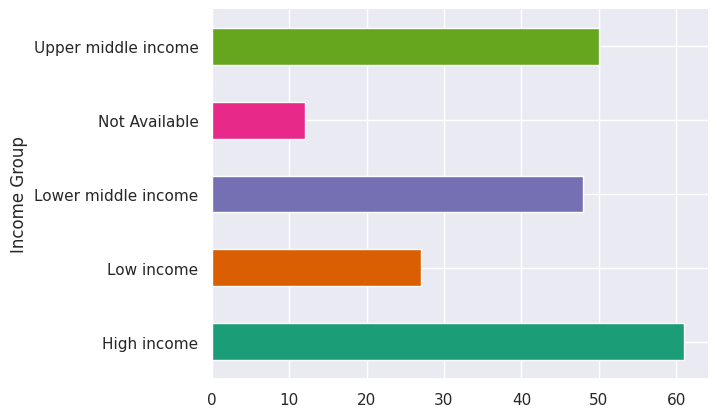

In [ ]:
# @title Income Group

from matplotlib import pyplot as plt
import seaborn as sns
dfh.groupby('Income Group').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

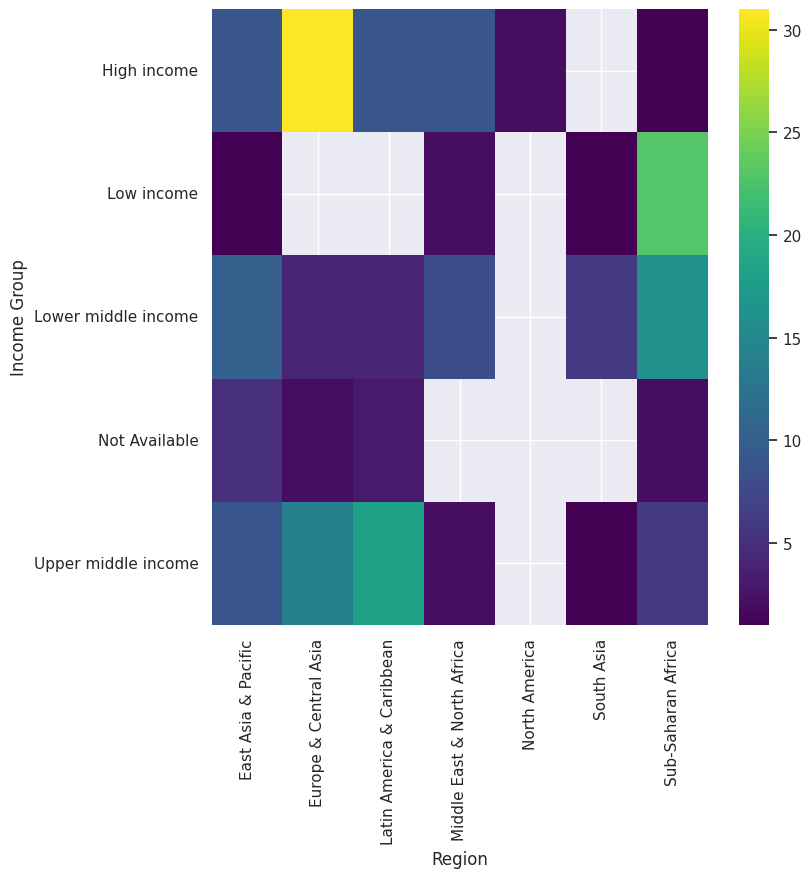

In [ ]:
# @title Region vs Income Group

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Income Group'].value_counts()
    for x_label, grp in dfh.groupby('Region')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Region')
_ = plt.ylabel('Income Group')

In [ ]:
columns_to_convert = ['Life Expectancy', 'Healthy Life Expectancy', 'Cancer', 'Suicide',
                      'Alcohol Consumption', 'Road Accidents', 'Obesity', 'Malaria',
                      'Hypertension', 'Tuberculosis', 'Sanitation']

# Convert specified columns to float
for col in columns_to_convert:
    dfh[col] = dfh[col].astype(float)

# Verify the updated data types
print(dfh.dtypes)

Countries and areas         object
Region                      object
Income Group                object
Life Expectancy            float64
Healthy Life Expectancy    float64
Cancer                     float64
Suicide                    float64
Alcohol Consumption        float64
Road Accidents             float64
Obesity                    float64
Malaria                    float64
Hypertension               float64
Tuberculosis               float64
Sanitation                 float64
dtype: object


In [ ]:
dfh.columns

Index(['Countries and areas', 'Region', 'Income Group', 'Life Expectancy',
       'Healthy Life Expectancy', 'Cancer', 'Suicide', 'Alcohol Consumption',
       'Road Accidents', 'Obesity', 'Malaria', 'Hypertension', 'Tuberculosis',
       'Sanitation'],
      dtype='object')

In [ ]:
df_le =dfh[['Region','Income Group','Life Expectancy', 'Healthy Life Expectancy',]]
df_le

,Region,Income Group,Life Expectancy,Healthy Life Expectancy
0,South Asia,Low income,63.2,53.9
1,Europe & Central Asia,Upper middle income,78.0,69.1
2,Middle East & North Africa,Lower middle income,77.1,66.4
3,Europe & Central Asia,High income,NaN,NaN
4,Sub-Saharan Africa,Lower middle income,63.1,54.8
...,...,...,...,...
193,Latin America & Caribbean,Upper middle income,73.9,64.4
194,East Asia & Pacific,Lower middle income,73.7,65.3
195,Middle East & North Africa,Low income,66.6,57.5
196,Sub-Saharan Africa,Lower middle income,62.5,54.4


<Axes: xlabel='Region', ylabel='Healthy Life Expectancy'>

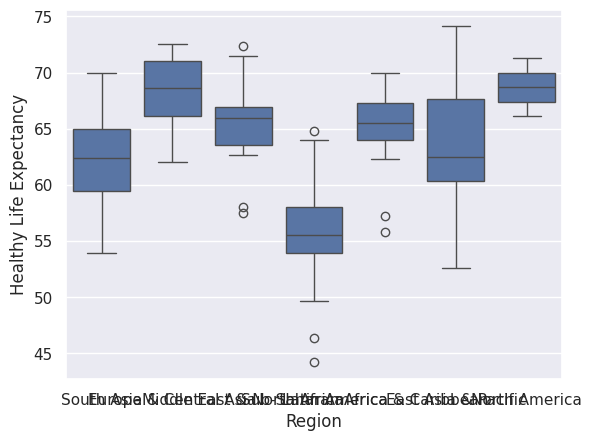

In [ ]:
# @title Healthy Life Expectancy by Region

sns.boxplot(data=df_le, x="Region", y="Healthy Life Expectancy")

In [ ]:
df_le.dtypes

Region                      object
Income Group                object
Life Expectancy            float64
Healthy Life Expectancy    float64
dtype: object

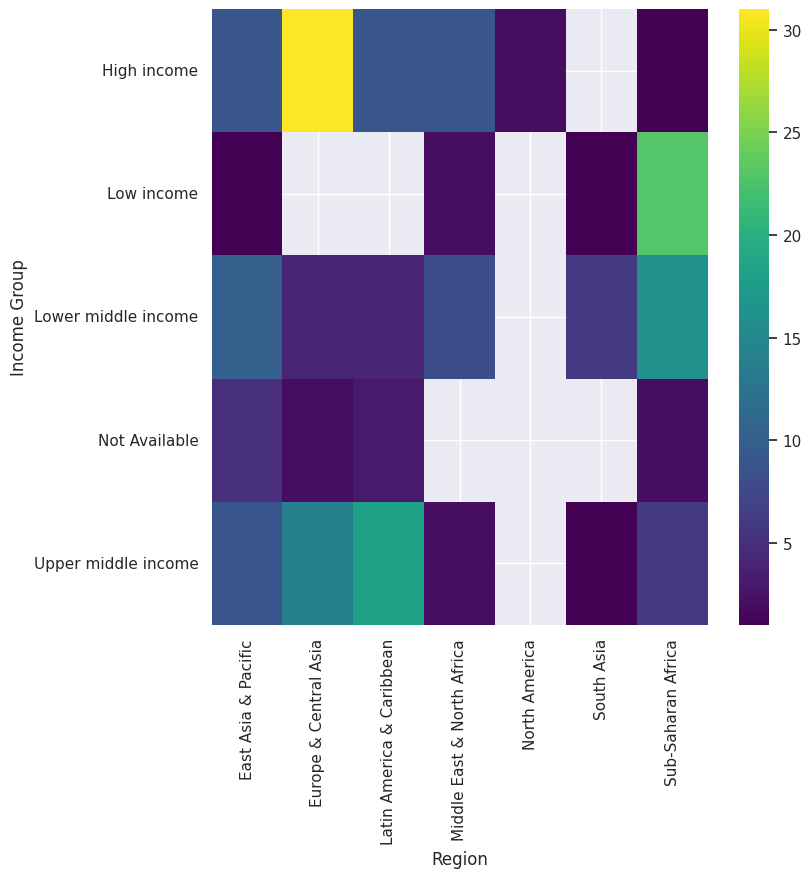

In [ ]:
# @title Region vs Income Group

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Income Group'].value_counts()
    for x_label, grp in df_le.groupby('Region')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Region')
_ = plt.ylabel('Income Group')

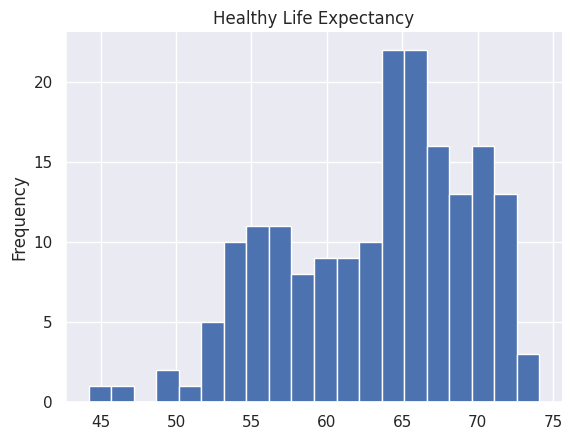

In [ ]:
from matplotlib import pyplot as plt
df_le['Healthy Life Expectancy'].plot(kind='hist', bins=20, title='Healthy Life Expectancy')
plt.gca().spines[['top', 'right',]].set_visible(False)

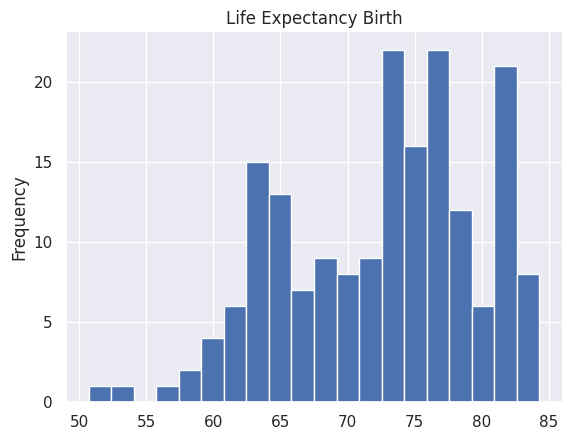

In [ ]:
from matplotlib import pyplot as plt
df_le['Life Expectancy'].plot(kind='hist', bins=20, title='Life Expectancy Birth')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
meanle_reg = df_le.groupby('Region')[['Life Expectancy', 'Healthy Life Expectancy']].mean()
meanle_reg

,Life Expectancy,Healthy Life Expectancy
Region,,
East Asia & Pacific,71.200000,62.764286
Latin America & Caribbean,74.377778,64.772222
Middle East & North Africa,72.920000,63.220000
South Asia,70.685714,61.014286
Sub-Saharan Africa,63.883721,55.644186


In [ ]:
import seaborn as sns

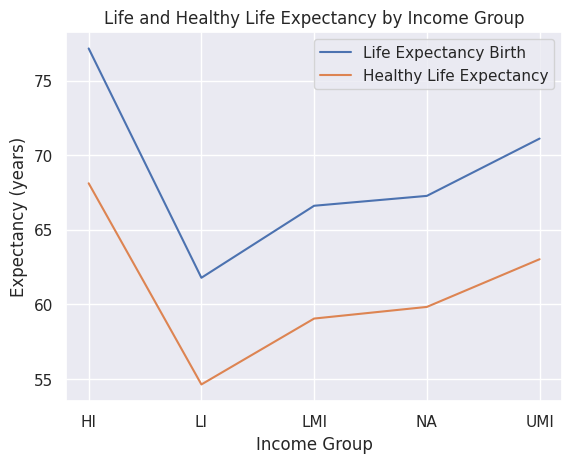

In [ ]:
import matplotlib.pyplot as plt

data = {'HI': (77.15094339622641, 68.11132075471698),
        'LI': (61.776, 54.623999999999995),
        'LMI': (66.60416666666667, 59.041666666666664),
        'NA': (67.26666666666667, 59.82222222222222),
        'UMI': (71.1086956521739, 63.0195652173913)}

regions = list(data.keys())
life_expectancy = [d[0] for d in data.values()]
healthy_life_expectancy = [d[1] for d in data.values()]

fig, ax = plt.subplots()
ax.plot(regions, life_expectancy, label='Life Expectancy Birth')
ax.plot(regions, healthy_life_expectancy, label='Healthy Life Expectancy')
ax.set_xlabel('Income Group')
ax.set_ylabel('Expectancy (years)')
ax.set_title('Life and Healthy Life Expectancy by Income Group')
ax.legend()
plt.show()

In [ ]:
dfa = dfh[['Income Group','Region','Alcohol Consumption']]
dfa

,Income Group,Region,Alcohol Consumption
0,Low income,South Asia,0.1
1,Upper middle income,Europe & Central Asia,5.1
2,Lower middle income,Middle East & North Africa,0.6
3,High income,Europe & Central Asia,11.1
4,Lower middle income,Sub-Saharan Africa,6.2
...,...,...,...
193,Upper middle income,Latin America & Caribbean,3.0
194,Lower middle income,East Asia & Pacific,9.3
195,Low income,Middle East & North Africa,0.1
196,Lower middle income,Sub-Saharan Africa,3.9


<ipython-input-99-8642df8ac946>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(dfa, x='Alcohol Consumption', y='Region', inner='stick', palette='Dark2')


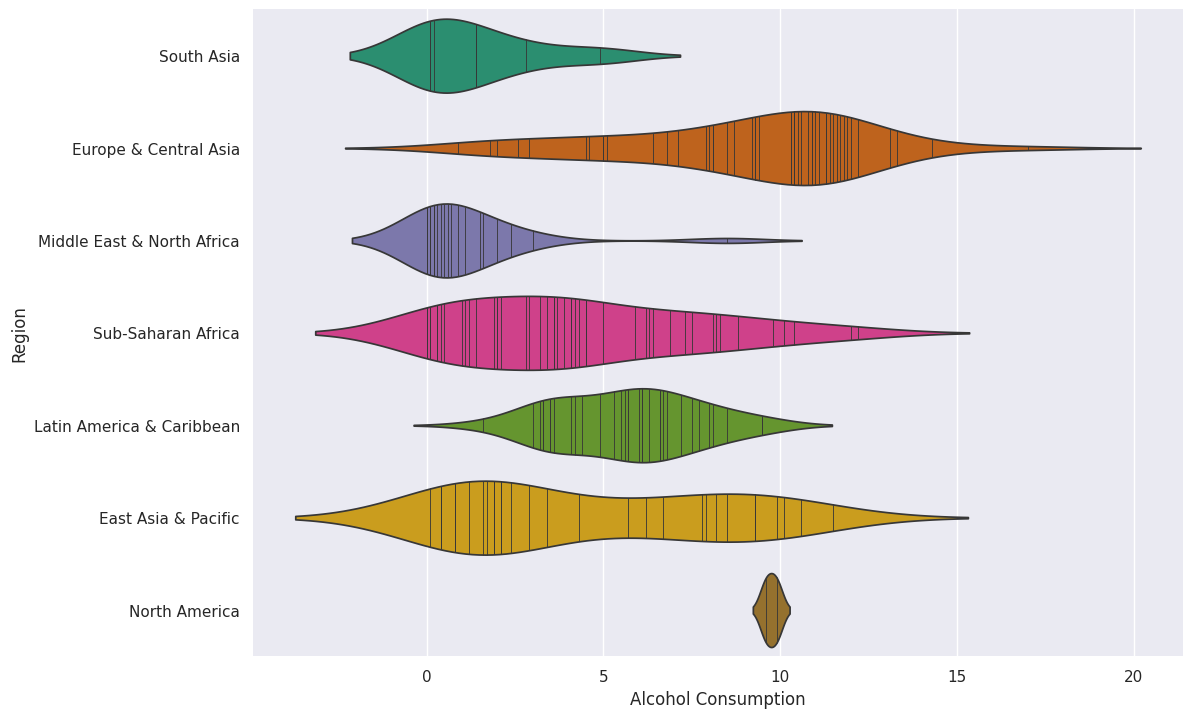

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(dfa['Region'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(dfa, x='Alcohol Consumption', y='Region', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<ipython-input-100-6eeb6eee6a53>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(dfa, x='Alcohol Consumption', y='Income Group', inner='stick', palette='Dark2')


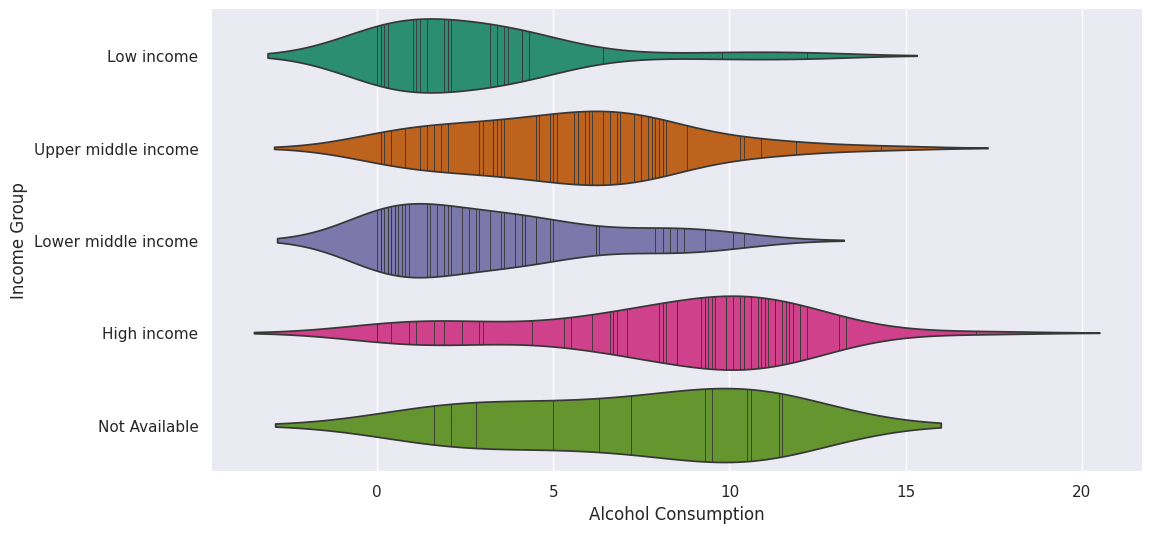

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(dfa['Income Group'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(dfa, x='Alcohol Consumption', y='Income Group', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
dfs =dfh[['Region','Income Group','Suicide']]
dfs

,Region,Income Group,Suicide
0,South Asia,Low income,4.1
1,Europe & Central Asia,Upper middle income,4.3
2,Middle East & North Africa,Lower middle income,2.5
3,Europe & Central Asia,High income,NaN
4,Sub-Saharan Africa,Lower middle income,6.1
...,...,...,...
193,Latin America & Caribbean,Upper middle income,2.0
194,East Asia & Pacific,Lower middle income,7.5
195,Middle East & North Africa,Low income,5.8
196,Sub-Saharan Africa,Lower middle income,7.3


<ipython-input-102-e95b7375ba15>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(dfs, x='Suicide', y='Income Group', inner='stick', palette='Dark2')


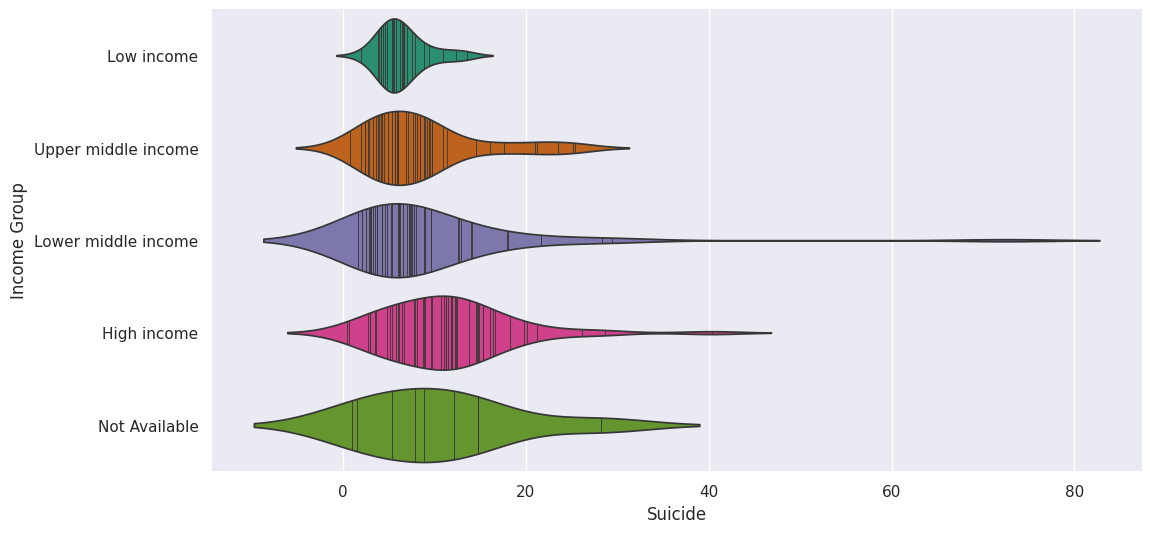

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(dfs['Income Group'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(dfs, x='Suicide', y='Income Group', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<ipython-input-103-4954ed4ff06e>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(dfs, x='Suicide', y='Region', inner='stick', palette='Dark2')


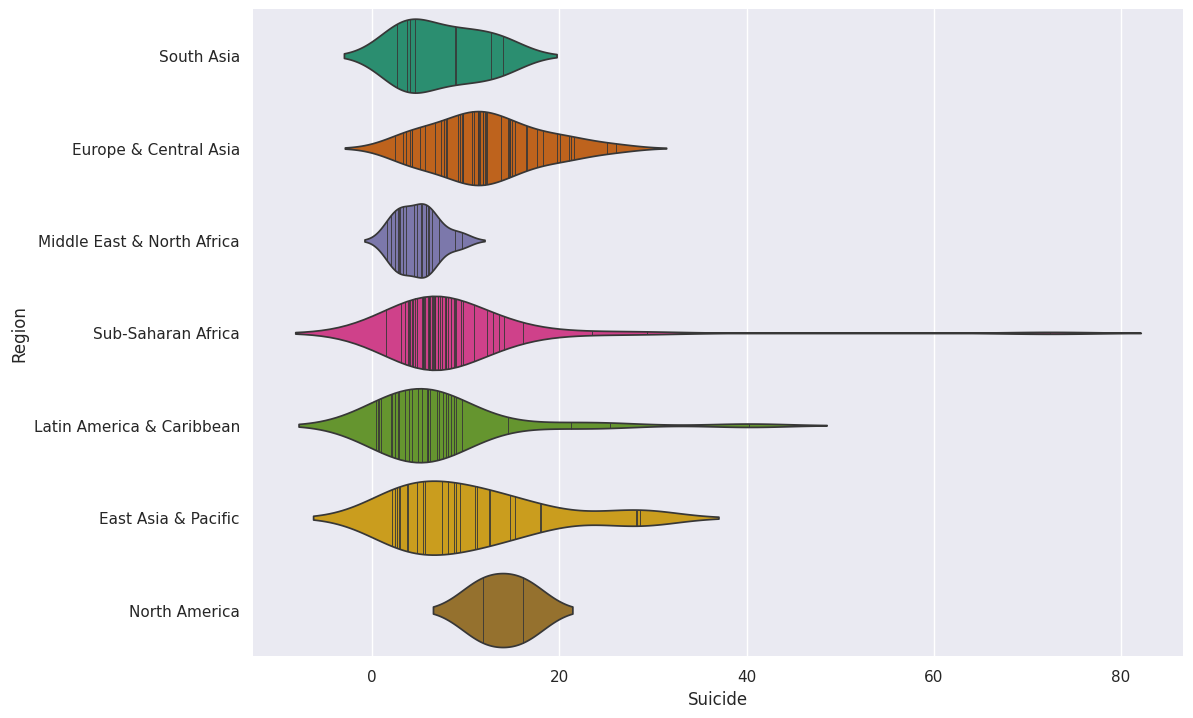

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(dfs['Region'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(dfs, x='Suicide', y='Region', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
mean_su = dfs.groupby(['Income Group', 'Region'])['Suicide'].mean().reset_index()
mean_su

,Income Group,Region,Suicide
0,High income,East Asia & Pacific,13.550000
1,High income,Europe & Central Asia,12.864286
2,High income,Latin America & Caribbean,10.825000
3,High income,Middle East & North Africa,5.775000
4,High income,North America,13.950000
5,High income,Sub-Saharan Africa,8.100000
6,Low income,East Asia & Pacific,9.400000
7,Low income,Middle East & North Africa,3.900000
8,Low income,South Asia,4.100000
9,Low income,Sub-Saharan Africa,6.665217


<Axes: xlabel='Income Group', ylabel='Suicide'>

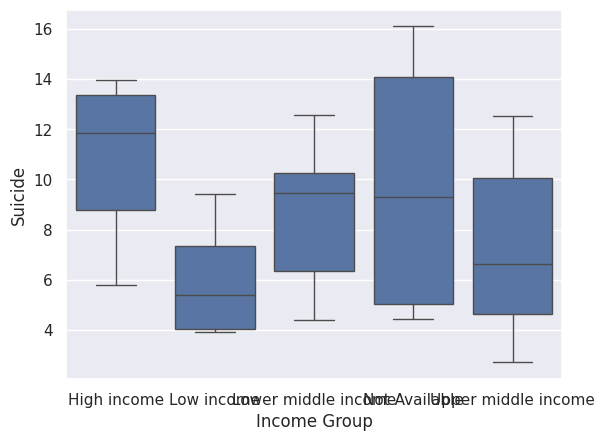

In [ ]:
# @title Suicide Rate by Income Group

sns.boxplot(x='Income Group', y='Suicide', data=mean_su)

In [ ]:
df_can = dfh[['Income Group','Cancer']]
df_can

,Income Group,Cancer
0,Low income,35.3
1,Upper middle income,11.4
2,Lower middle income,13.9
3,High income,NaN
4,Lower middle income,22.2
...,...,...
193,Upper middle income,14.8
194,Lower middle income,21.2
195,Low income,27.6
196,Lower middle income,24.6


<ipython-input-108-27a1386104ae>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df_can, x='Cancer', y='Income Group', inner='stick', palette='Dark2')


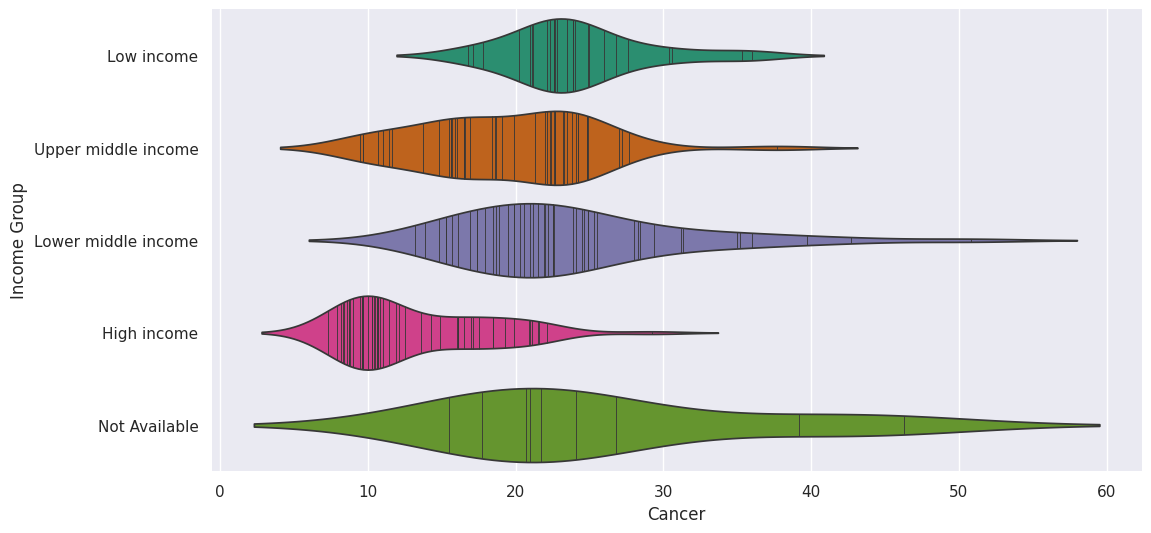

In [ ]:
# @title Income Group vs Cancer Deaths

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df_can['Income Group'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_can, x='Cancer', y='Income Group', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
mean_can = dfh.groupby('Region')['Cancer'].mean()
mean_can

Region
East Asia & Pacific           24.603846
Europe & Central Asia         16.495833
Latin America & Caribbean     16.719355
Middle East & North Africa    18.220000
North America                 11.600000
South Asia                    21.287500
Sub-Saharan Africa            23.400000
Name: Cancer, dtype: float64

In [ ]:
dftm = dfh[['Region','Income Group','Malaria','Tuberculosis']]
dftm

,Region,Income Group,Malaria,Tuberculosis
0,South Asia,Low income,6.3,189.0
1,Europe & Central Asia,Upper middle income,NaN,17.0
2,Middle East & North Africa,Lower middle income,0.0,54.0
3,Europe & Central Asia,High income,NaN,2.9
4,Sub-Saharan Africa,Lower middle income,254.9,325.0
...,...,...,...,...
193,Latin America & Caribbean,Upper middle income,14.5,47.0
194,East Asia & Pacific,Lower middle income,0.1,173.0
195,Middle East & North Africa,Low income,46.1,48.0
196,Sub-Saharan Africa,Lower middle income,187.7,307.0


In [ ]:
mean_m = dfh.groupby('Region')['Malaria'].mean()
mean_m

Region
East Asia & Pacific            25.600000
Europe & Central Asia                NaN
Latin America & Caribbean       4.555556
Middle East & North Africa     11.660000
North America                        NaN
South Asia                      1.771429
Sub-Saharan Africa            179.068889
Name: Malaria, dtype: float64

In [ ]:
mean_t = dfh.groupby('Region')['Tuberculosis'].mean()
mean_t

Region
East Asia & Pacific           181.550000
Europe & Central Asia          22.362745
Latin America & Caribbean      35.158824
Middle East & North Africa     32.390476
North America                   3.950000
South Asia                    172.250000
Sub-Saharan Africa            208.416667
Name: Tuberculosis, dtype: float64

In [ ]:
dfh.head(5)

,Countries and areas,Region,Income Group,Life Expectancy,Healthy Life Expectancy,Cancer,Suicide,Alcohol Consumption,Road Accidents,Obesity,Malaria,Hypertension,Tuberculosis,Sanitation
0,Afghanistan,South Asia,Low income,63.2,53.9,35.3,4.1,0.1,15.9,5.5,6.3,40.2,189.0,16.6
1,Albania,Europe & Central Asia,Upper middle income,78.0,69.1,11.4,4.3,5.1,11.7,21.7,NaN,41.8,17.0,3.2
2,Algeria,Middle East & North Africa,Lower middle income,77.1,66.4,13.9,2.5,0.6,20.9,27.4,0.0,36.2,54.0,4.1
3,Andorra,Europe & Central Asia,High income,NaN,NaN,NaN,NaN,11.1,NaN,25.6,NaN,31.0,2.9,NaN
4,Angola,Sub-Saharan Africa,Lower middle income,63.1,54.8,22.2,6.1,6.2,26.1,8.2,254.9,38.7,325.0,48.9


In [ ]:
df4 = dfh[['Region','Income Group','Road Accidents']]
df4

,Region,Income Group,Road Accidents
0,South Asia,Low income,15.9
1,Europe & Central Asia,Upper middle income,11.7
2,Middle East & North Africa,Lower middle income,20.9
3,Europe & Central Asia,High income,NaN
4,Sub-Saharan Africa,Lower middle income,26.1
...,...,...,...
193,Latin America & Caribbean,Upper middle income,39.0
194,East Asia & Pacific,Lower middle income,30.6
195,Middle East & North Africa,Low income,29.4
196,Sub-Saharan Africa,Lower middle income,20.5


In [ ]:
mean_r = dfh.groupby('Region')['Road Accidents'].mean()
mean_r

Region
East Asia & Pacific           14.726923
Europe & Central Asia          7.487500
Latin America & Caribbean     17.654839
Middle East & North Africa    16.355000
North America                  9.000000
South Asia                    14.200000
Sub-Saharan Africa            28.716667
Name: Road Accidents, dtype: float64

In [ ]:
mean_rr = dfh.groupby('Income Group')['Road Accidents'].mean()
mean_rr

Income Group
High income             7.500000
Low income             29.800000
Lower middle income    20.172917
Not Available          15.244444
Upper middle income    17.806522
Name: Road Accidents, dtype: float64

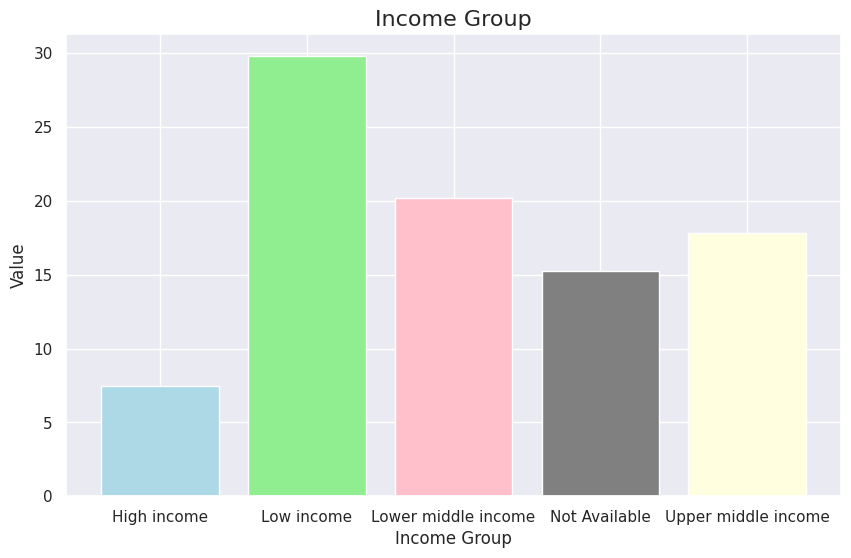

In [ ]:
import matplotlib.pyplot as plt

# Income Group data
income_group = ['High income', 'Low income', 'Lower middle income', 'Not Available', 'Upper middle income']
values = [7.500000, 29.800000, 20.172917, 15.244444, 17.806522]

# Create a bar chart
plt.figure(figsize=(10,6))
plt.bar(income_group, values, color=['lightblue', 'lightgreen', 'pink', 'gray', 'lightyellow'])

# Add title and labels
plt.title('Income Group', fontsize=16)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Value', fontsize=12)

# Show the chart
plt.show()

In [ ]:
dfsan = dfh[['Region','Income Group','Sanitation']]
dfsan

,Region,Income Group,Sanitation
0,South Asia,Low income,16.6
1,Europe & Central Asia,Upper middle income,3.2
2,Middle East & North Africa,Lower middle income,4.1
3,Europe & Central Asia,High income,NaN
4,Sub-Saharan Africa,Lower middle income,48.9
...,...,...,...
193,Latin America & Caribbean,Upper middle income,5.2
194,East Asia & Pacific,Lower middle income,6.9
195,Middle East & North Africa,Low income,15.6
196,Sub-Saharan Africa,Lower middle income,35.8


In [ ]:
mean_sa = dfh.groupby('Income Group')['Sanitation'].mean()
mean_sa

Income Group
High income             3.496226
Low income             46.525926
Lower middle income    24.075000
Not Available          16.577778
Upper middle income     7.776087
Name: Sanitation, dtype: float64

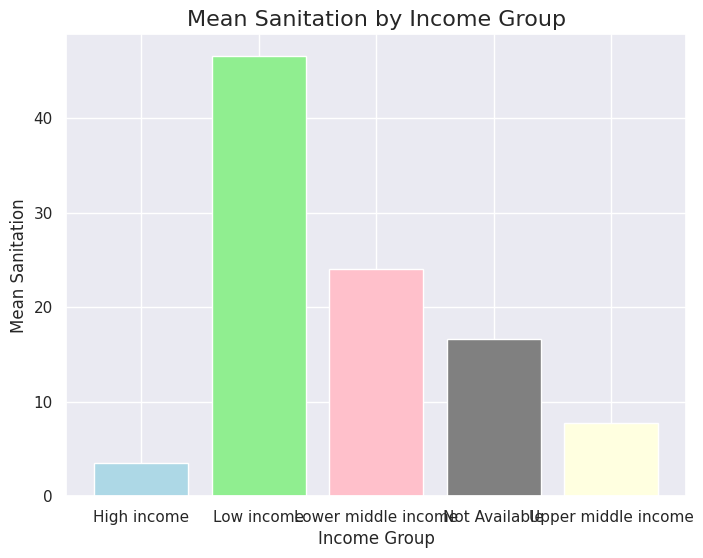

In [ ]:
import matplotlib.pyplot as plt

# Mean sanitation by income group
mean_sa = dfh.groupby('Income Group')['Sanitation'].mean()

# Create a bar chart
plt.figure(figsize=(8,6))
plt.bar(mean_sa.index, mean_sa.values, color=['lightblue', 'lightgreen', 'pink', 'gray', 'lightyellow'])

# Add title and labels
plt.title('Mean Sanitation by Income Group', fontsize=16)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Mean Sanitation', fontsize=12)

# Show the chart
plt.show()

In [ ]:
mean_san = dfh.groupby('Region')['Sanitation'].mean()
mean_san

Region
East Asia & Pacific           12.850000
Europe & Central Asia          3.437500
Latin America & Caribbean      6.548387
Middle East & North Africa     5.280000
North America                  2.300000
South Asia                    18.825000
Sub-Saharan Africa            44.606250
Name: Sanitation, dtype: float64

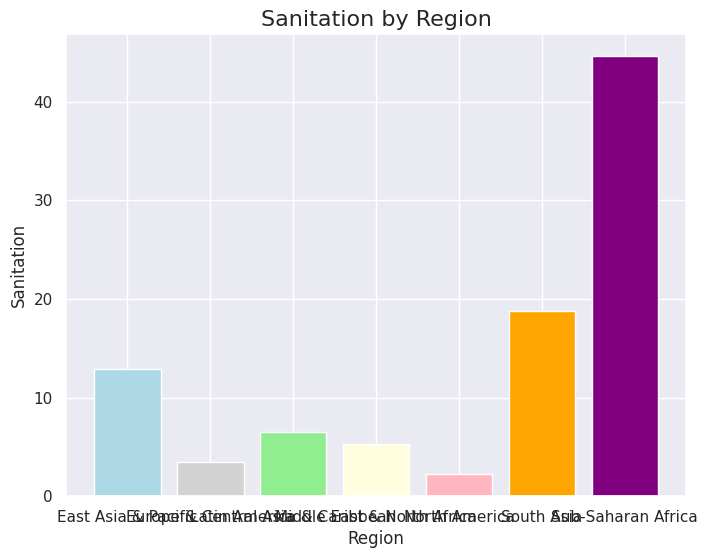

In [ ]:
import matplotlib.pyplot as plt

# Sanitation by region
sanitation_by_region = dfh.groupby('Region')['Sanitation'].mean()

# Create a bar chart
plt.figure(figsize=(8,6))
plt.bar(sanitation_by_region.index, sanitation_by_region.values, color=['lightblue', 'lightgray', 'lightgreen', 'lightyellow', 'lightpink', 'orange', 'purple'])

# Add title and labels
plt.title('Sanitation by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Sanitation', fontsize=12)

# Show the chart
plt.show()

In [ ]:
X = df2[['Suicide','Cancer', 'Alcohol Consumption', 'Road Accidents', 'Obesity',
        'Malaria','Tuberculosis','Sanitation']]
y = df2['Life Expectancy']
# Split data into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create linear regression model
regression = LinearRegression()
# Train the model
regression.fit(X_train, y_train)
# Evaluate the model
y_pred = regression.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r_squared)

# Print regression equation coefficients
print("Regression Equation Coefficients:", regression.coef_)
print("Regression Equation Intercept:", regression.intercept_)

Mean Squared Error: 3.75483134725383
R-squared: 0.8199741127681963
Regression Equation Coefficients: [-0.03897592 -0.40291702 -0.04520396 -0.09972222 -0.00596732 -0.00732086
 -0.00724266 -0.12017397]
Regression Equation Intercept: 85.46874728800641


     Suicide  Cancer  Alcohol Consumption  Road Accidents  Obesity  Malaria  \
0        4.1    35.3                  0.1            15.9      5.5      6.3   
2        2.5    13.9                  0.6            20.9     27.4      0.0   
4        6.1    22.2                  6.2            26.1      8.2    254.9   
13       3.7    18.9                  0.1            15.3      3.6      0.5   
17       7.1    16.5                  5.7            22.6     24.1      0.0   
..       ...     ...                  ...             ...      ...      ...   
193      2.0    14.8                  3.0            39.0     25.6     14.5   
194      7.5    21.2                  9.3            30.6      2.1      0.1   
195      5.8    27.6                  0.1            29.4     17.1     46.1   
196      7.3    24.6                  3.9            20.5      8.1    187.7   
197     14.1    28.4                  3.6            41.2     15.5     27.2   

     Tuberculosis  Sanitation  
0           189.0  

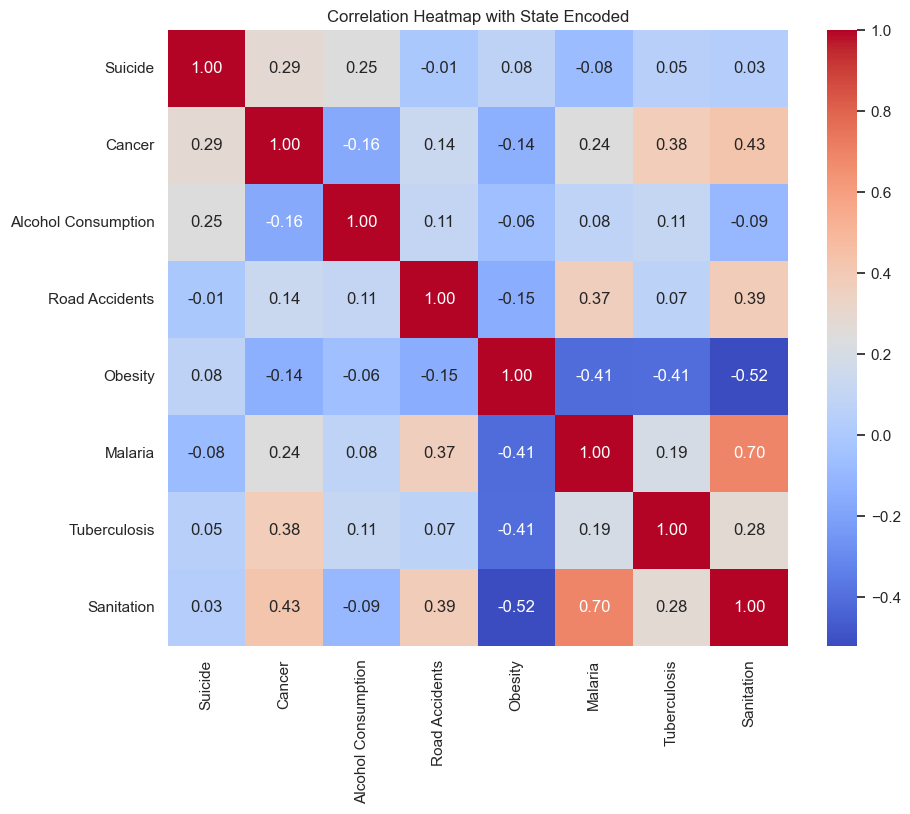

In [ ]:
# Initialize the label encoder
label_encoder = LabelEncoder()
# Now drop the original 'State' column
encoded_data = df2.drop('Life Expectancy', axis=1)
print(encoded_data)
# Calculate the correlation matrix
corr_matrix = encoded_data.corr()

# Generate a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap with State Encoded')
plt.show()

In [ ]:
vif = pd.DataFrame()
vif['Features'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,Cancer,16.33
3,Road Accidents,8.23
7,Sanitation,7.00
4,Obesity,5.15
5,Malaria,3.56
6,Tuberculosis,3.56
0,Suicide,3.31
2,Alcohol Consumption,3.00


In [ ]:
import statsmodels.api as sm
# Add a constant
X_train_lm1 = sm.add_constant(X_train)
# Create a first fitted model
lr1 = sm.OLS(y_train, X_train_lm1).fit()

In [ ]:
# Check the parameters obtained
lr1.params

const                  85.468747
Suicide                -0.038976
Cancer                 -0.402917
Alcohol Consumption    -0.045204
Road Accidents         -0.099722
Obesity                -0.005967
Malaria                -0.007321
Tuberculosis           -0.007243
Sanitation             -0.120174
dtype: float64

In [ ]:
# Print a summary of the linear regression model obtained
print(lr1.summary())

                            OLS Regression Results                            
Dep. Variable:        Life Expectancy   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     98.55
Date:                Mon, 15 Apr 2024   Prob (F-statistic):           5.43e-33
Time:                        10:53:50   Log-Likelihood:                -145.35
No. Observations:                  73   AIC:                             308.7
Df Residuals:                      64   BIC:                             329.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  85.4687    

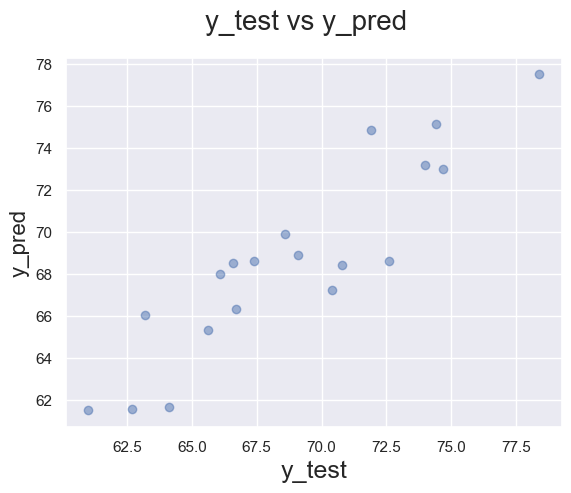

In [ ]:
fig = plt.figure()
plt.scatter(y_test, y_pred, alpha=.5)
fig.suptitle('y_test vs y_pred', fontsize = 20)              # Plot heading
plt.xlabel('y_test', fontsize = 18)                          # X-label
plt.ylabel('y_pred', fontsize = 16)
plt.show()

C:\Users\manna\AppData\Local\Temp\ipykernel_4340\903834468.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((res), bins = 20)


Text(0.5, 0, 'Errors')

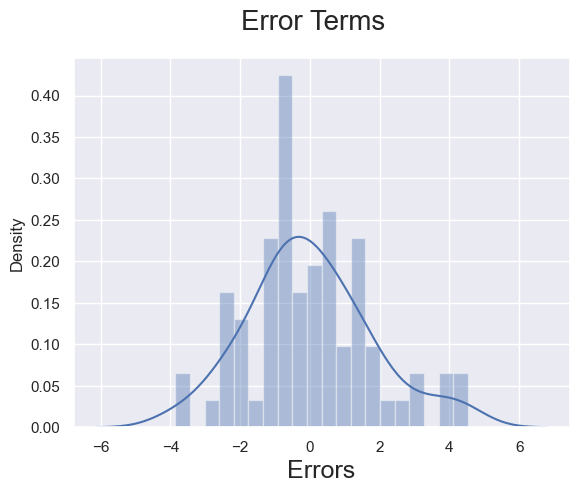

In [ ]:
y_train_pred = regression.predict(X_train)
res = y_train-y_train_pred
# Plot the histogram of the error terms
fig = plt.figure()
sns.distplot((res), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                  # Plot heading
plt.xlabel('Errors', fontsize = 18)                         # X-label